In [2]:
!pip uninstall jax jaxlib -y
!pip install tensorflow==2.15

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
ERROR: Could not find a version that satisfies the requirement tensorflow==2.15 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15


In [3]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential # model where layers are stacked one after another
from keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D
from keras import backend as K

# Conv2D → extract features from images
# MaxPooling2D → reduce size
# Flatten → convert 2D → 1D
# Dense → fully connected layer
# Dropout → prevent overfitting

In [4]:
num_classes = 10 # 10 output classes
batch_size = 64 # Train 64 images at a time
epochs = 24 # Train the model 24 times over full dataset

In [5]:
# input image dimensions
img_rows,img_cols=28,28  #  Each image is 28×28 pixels

(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()
print(x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)


In [6]:
x_train = x_train.reshape(x_train.shape[0] ,img_rows,img_cols,1)
x_test = x_test.reshape(x_test.shape[0] ,img_rows,img_cols,1)
input_shape = (img_rows,img_cols,1)
print('x_train shape : ',x_train.shape)
print('x_test shape : ',x_test.shape)

# Convert to CNN format:
# From:
# (60000, 28, 28)
# To:
# (60000, 28, 28, 1)
# 👉 1 = grayscale channel

x_train shape :  (60000, 28, 28, 1)
x_test shape :  (10000, 28, 28, 1)


In [7]:
# type convert and scale the test and training data (feature scaling)
# A grayscale image has only one channel that represents intensity (brightness).
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train/255  # 0–255 → 0–1
x_test = x_test/255
print('x_train shape : ',x_train.shape)
print('x_test shape : ',x_test.shape)
print(y_train[0:3])

x_train shape :  (60000, 28, 28, 1)
x_test shape :  (10000, 28, 28, 1)
[9 0 0]


In [8]:
# convert class vectors to binary class matrices - One-hot encoding
# 3 => 001000000 and 1 => 010000000

y_train = tf.keras.utils.to_categorical(y_train,num_classes)
y_test = tf.keras.utils.to_categorical(y_test,num_classes)
print(y_train[0:2])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [9]:
model = Sequential()

In [10]:
# create a cnn to classify the images

# First convolution layer
# 32 filters
# 3×3 kernel
# extracts features like edges

model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(num_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# define compile to minimize categorica; loss,use ada delta optimised and optimise to maximise accuracy

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=keras.optimizers.Adam(),
              metrics=['accuracy'])

# 👉 Defines:
# Loss → error function
# Optimizer → how weights update
# Metric → what to track

# return history of loss and accuracy of epoch

hist = model.fit(x_train,y_train,
                 batch_size=batch_size,
                 epochs = epochs,
                 verbose=1,
                 validation_data=(x_test,y_test))

Epoch 1/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.8084 - loss: 0.5241 - val_accuracy: 0.8618 - val_loss: 0.3816
Epoch 2/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.8786 - loss: 0.3316 - val_accuracy: 0.8743 - val_loss: 0.3439
Epoch 3/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.8926 - loss: 0.2883 - val_accuracy: 0.8808 - val_loss: 0.3198
Epoch 4/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.9047 - loss: 0.2572 - val_accuracy: 0.8987 - val_loss: 0.2769
Epoch 5/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9135 - loss: 0.2339 - val_accuracy: 0.8981 - val_loss: 0.2838
Epoch 6/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.9194 - loss: 0.2172 - val_accuracy: 0.9019 - val_loss: 0.2651
Epoch 7/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9256 - loss: 0.1991 - val_accuracy: 0.9057 - val_loss: 0.2587
Epoch 8/24
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9294 - loss: 0.1878 - 

In [13]:
print(hist.history)


{'accuracy': [0.8084166646003723, 0.8786166906356812, 0.8925666809082031, 0.9047166705131531, 0.9135333299636841, 0.9194333553314209, 0.9256166815757751, 0.9294333457946777, 0.9362499713897705, 0.941349983215332, 0.9466833472251892, 0.9497166872024536, 0.9540833234786987, 0.9569000005722046, 0.9599999785423279, 0.9636333584785461, 0.965749979019165, 0.9702333211898804, 0.971750020980835, 0.9736999869346619, 0.9752833247184753, 0.9781500101089478, 0.9795666933059692, 0.9797499775886536], 'loss': [0.524141788482666, 0.3316496014595032, 0.28827837109565735, 0.25716450810432434, 0.23393595218658447, 0.21722149848937988, 0.19908744096755981, 0.18780480325222015, 0.17070944607257843, 0.15691985189914703, 0.14466118812561035, 0.13377691805362701, 0.12413808703422546, 0.11499690264463425, 0.1061943918466568, 0.0973450243473053, 0.08953600376844406, 0.07973698526620865, 0.07544374465942383, 0.07034748792648315, 0.06576801836490631, 0.05908442288637161, 0.055222831666469574, 0.053401216864585876

test loss :  0.4235694706439972
test accuracy :  0.9067999720573425


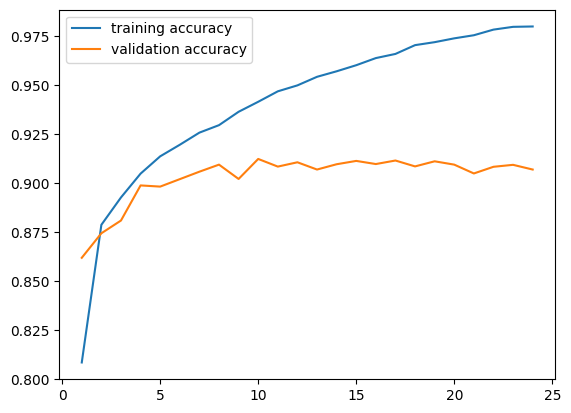

In [14]:
# evaluate the model with the test data to get the scores on real data
score = model.evaluate(x_test,y_test,verbose=0)
print('test loss : ',score[0])
print('test accuracy : ',score[1])

# plot data to see relationship in trainiig and validationj data

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

epoch_list = list(range(1,len(hist.history['accuracy'])+1))
plt.plot(epoch_list,hist.history['accuracy'],epoch_list,hist.history['val_accuracy'])
plt.legend(('training accuracy','validation accuracy'))
plt.show()

In [18]:
img = x_test[0]   # pick first test image
img = img.reshape(1, 28, 28, 1)
prediction = model.predict(img)
print(prediction)
import numpy as np
predicted_class = np.argmax(prediction)

print("Predicted:", predicted_class)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Predicted:", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[1.3844660e-13 6.4845097e-13 2.0666279e-14 6.4463029e-14 2.8823353e-16
  4.1737486e-10 3.0850651e-09 9.5827550e-09 1.9367720e-14 1.0000000e+00]]
Predicted: 9
Predicted: Ankle boot
